### Objectives
- Train a baseline Linear Regression model
- Train advanced ensemble models: Random Forest & XGBoost
- Use TimeSeriesSplit cross-validation (no data leakage)
- Perform hyperparameter tuning
- Compare all models systematically

## **Load Feature-Engineered Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error
from sklearn.preprocessing   import StandardScaler
import xgboost as xgb

In [5]:
df= pd.read_csv('Data/Restaurant_sales.csv', parse_dates=['date'])
df

,date,item,sales,is_weekend,is_holiday,is_festival,promo_active,temperature_celsius,rainfall_mm
0,2022-01-01,Burger,224,1,0,1,0,21.6,0.3
1,2022-01-01,Pizza,164,1,0,1,0,21.6,0.3
2,2022-01-01,Pasta,149,1,0,1,0,21.6,0.3
3,2022-01-01,Salad,98,1,0,1,0,21.6,0.3
4,2022-01-02,Burger,112,1,0,0,0,22.2,0.2
...,...,...,...,...,...,...,...,...,...
2915,2023-12-30,Salad,81,1,0,0,1,16.4,0.2
2916,2023-12-31,Burger,191,1,0,0,1,18.1,3.4
2917,2023-12-31,Pizza,144,1,0,0,1,18.1,3.4
2918,2023-12-31,Pasta,129,1,0,0,1,18.1,3.4


In [9]:
from Preprocessing      import load_data, train_test_split_ts

In [21]:
def build_feature_matrix(df, target_col="sales"):
    # Add features
    df = add_calendar_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_external_features(df)

    # Remove missing rows
    df = df.dropna()

    # Remove unwanted columns
    drop_cols = [target_col, "item", "day_name"]

    X = df.drop(columns=drop_cols, errors='ignore')
    y = df[target_col]

    return X, y

In [25]:
def add_external_features(df):
    df = df.copy()

    # Temperature features
    df["is_hot_day"] = (df["temperature_celsius"] > 27).astype(int)
    df["temp_rolling_7"] = df["temperature_celsius"].rolling(7).mean()

    # Rain features
    df["is_rainy_day"] = (df["rainfall_mm"] > 5).astype(int)
    df["is_heavy_rain"] = (df["rainfall_mm"] > 15).astype(int)

    # Promo streak
    streak = 0
    promo_days = []

    for i in df["promo_active"]:
        if i == 1:
            streak += 1
        else:
            streak = 0
        promo_days.append(streak)

    df["promo_streak"] = promo_days

    # Festival or holiday
    df["festival_or_holiday"] = (
        (df["is_festival"] == 1) | (df["is_holiday"] == 1)
    ).astype(int)

    return df

In [26]:
def add_calendar_features(df):
    df = df.copy()

    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    df["week_of_year"] = df.index.isocalendar().week.astype(int)
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
    df["day_name"] = df.index.day_name()

    return df

In [27]:
def add_lag_features(df, column="sales", lags=[1, 7, 14, 21, 28]):
    df = df.copy()

    for lag in lags:
        df["lag_" + str(lag)] = df[column].shift(lag)

    return df

In [28]:
def add_rolling_features(df, column="sales", windows=[7, 14, 30]):
    df = df.copy()

    for w in windows:
        data = df[column].shift(1).rolling(w)

        df["rolling_mean_" + str(w)] = data.mean()
        df["rolling_std_" + str(w)] = data.std()
        df["rolling_max_" + str(w)] = data.max()
        df["rolling_min_" + str(w)] = data.min()

    return df

### **Load and split**

In [ ]:
df = load_data(item='Burger')
train_df, test_df = train_test_split_ts(df.dropna(), test_months=2)

X_train, y_train = build_feature_matrix(train_df)
X_test,  y_test  = build_feature_matrix(test_df)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

   Train: 2022-01-01 → 2023-10-31  (669 rows)
   Test : 2023-11-01  → 2023-12-31   (61 rows)
X_train: (639, 34), X_test: (31, 34)
X_train: (639, 34)
X_test : (31, 34)


##  **Evaluation Helper Function**

##### Centralised evaluation function

In [37]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    print("Train model")
    model.fit(X_train, y_train)

    print("predict")
    pred = model.predict(X_test)

    print("metrics")
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(abs((y_test - pred) / y_test)) * 100

    print("-" * 40)
    print("Model :", name)
    print("MAE   :", round(mae, 2))
    print("RMSE  :", round(rmse, 2))
    print("MAPE  :", round(mape, 2), "%")
    print("-" * 40)
   
    return {
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'predictions': pred,
        'fitted_model': model
    }

# Store all model results
results = []

## **Baseline: Linear Regression**

Baseline model 

Linear Regression assumes a straight-line relationship between features and target.

 It's our baseline — anything better than this is a real improvement.

In [38]:
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

model = LinearRegression()
model_result = evaluate_model('Linear Regression', model, X_tr_sc, y_train, X_te_sc, y_test)
results.append(model_result)

Train model
predict
metrics
----------------------------------------
Model : Linear Regression
MAE   : 25.85
RMSE  : 37.94
MAPE  : 13.53 %
----------------------------------------


## **Random Forest Regressor**

 Random Forest (ensemble of decision trees)

 Each tree sees a random subset of features → reduces overfitting.
 
 No scaling needed — tree models are scale-invariant.

In [41]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_result = evaluate_model('Random Forest', rf_model, X_train, y_train, X_test, y_test)
results.append(rf_result)

Train model
predict
metrics
----------------------------------------
Model : Random Forest
MAE   : 31.96
RMSE  : 55.61
MAPE  : 14.52 %
----------------------------------------


## **XGBoost Regressor**

In [43]:
# Sequentially corrects errors of previous trees → very powerful for tabular data.
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb_result = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)
results.append(xgb_result)

Train model
predict
metrics
----------------------------------------
Model : XGBoost
MAE   : 26.69
RMSE  : 47.68
MAPE  : 12.76 %
----------------------------------------


## **Time-Series Cross-Validation**

TimeSeriesSplit ensures validation folds are always in the future 

This is CRITICAL for time-series — random k-fold would leak future data into training

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

print("5-Fold Cross Validation")

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Check each model
for name, model in models.items():

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error'
    )

    print(name)
    print("MAE:", round(-score.mean(), 2))
    print("Std:", round(score.std(), 2))
    print()

5-Fold Cross Validation
Random Forest
MAE: 15.73
Std: 3.1

XGBoost
MAE: 15.95
Std: 3.92



## **Hyperparameter Tuning (XGBoost)**

Grid Search with TimeSeriesSplit

In [ ]:
# Parameters
params = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.7, 0.9]
}

# Time series split
tscv = TimeSeriesSplit(n_splits=3)

# Grid Search
model = xgb.XGBRegressor(random_state=42, verbosity=0)

grid = GridSearchCV(
    model,
    params,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV MAE:", round(-grid.best_score_, 2))

Best Parameters: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
Best CV MAE: 13.49


In [ ]:
model = grid.best_estimator_
result = evaluate_model(
    'XGBoost (Tuned)',
    model,
    X_train, y_train,
    X_test, y_test
)
results.append(result)

Train model
predict
metrics
----------------------------------------
Model : XGBoost (Tuned)
MAE   : 29.35
RMSE  : 55.45
MAPE  : 13.59 %
----------------------------------------


## **Model Comparison**

Compare all models on test set

Model Comparison
                      MAE    RMSE    MAPE
model                                    
Linear Regression  25.853  37.937  13.526
Linear Regression  25.853  37.937  13.526
Random Forest      31.963  55.611  14.516
Random Forest      31.963  55.611  14.516
Random Forest      31.963  55.611  14.516
XGBoost            26.689  47.675  12.758
XGBoost (Tuned)    29.345  55.450  13.591


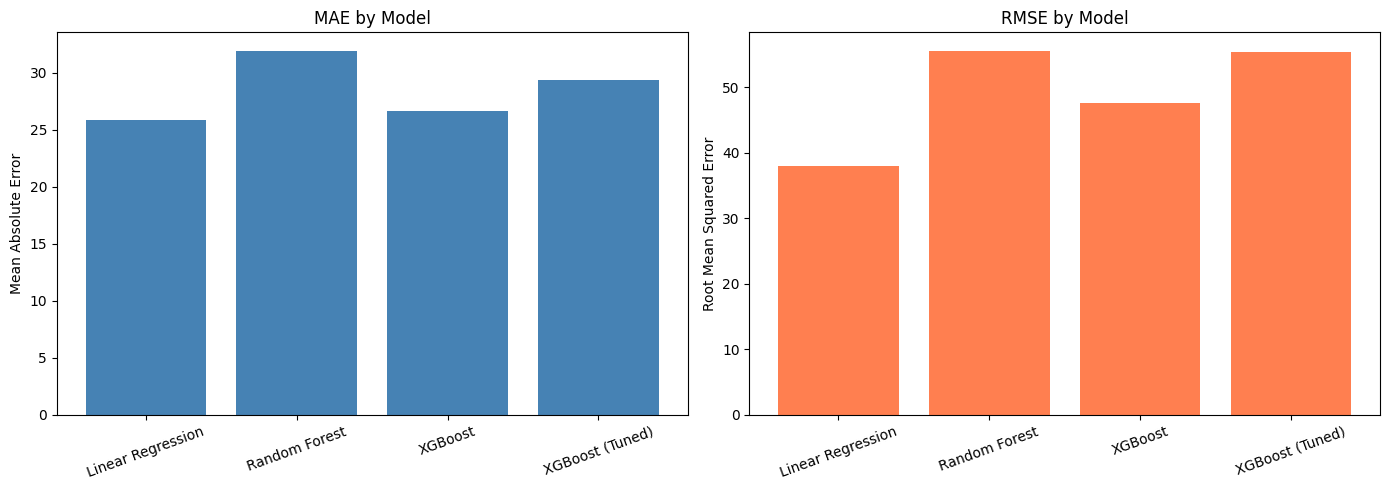

In [ ]:
# Create table
data = []

for r in results:
    data.append({
        'model': r['model'],
        'MAE': r['MAE'],
        'RMSE': r['RMSE'],
        'MAPE': r['MAPE']
    })

comparison_df = pd.DataFrame(data)

print("Model Comparison")
print(comparison_df.set_index('model').round(3).to_string())

plt.figure(figsize=(14,5))

# MAE chart
plt.subplot(1,2,1)
plt.bar(comparison_df['model'], comparison_df['MAE'], color='steelblue')
plt.title('MAE by Model')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=20)

# RMSE chart
plt.subplot(1,2,2)
plt.bar(comparison_df['model'], comparison_df['RMSE'], color='coral')
plt.title('RMSE by Model')
plt.ylabel('Root Mean Squared Error')
plt.xticks(rotation=20)
plt.show()

Plot best model predictions vs actuals on test set

Best model: Linear Regression (MAE = 25.85 )


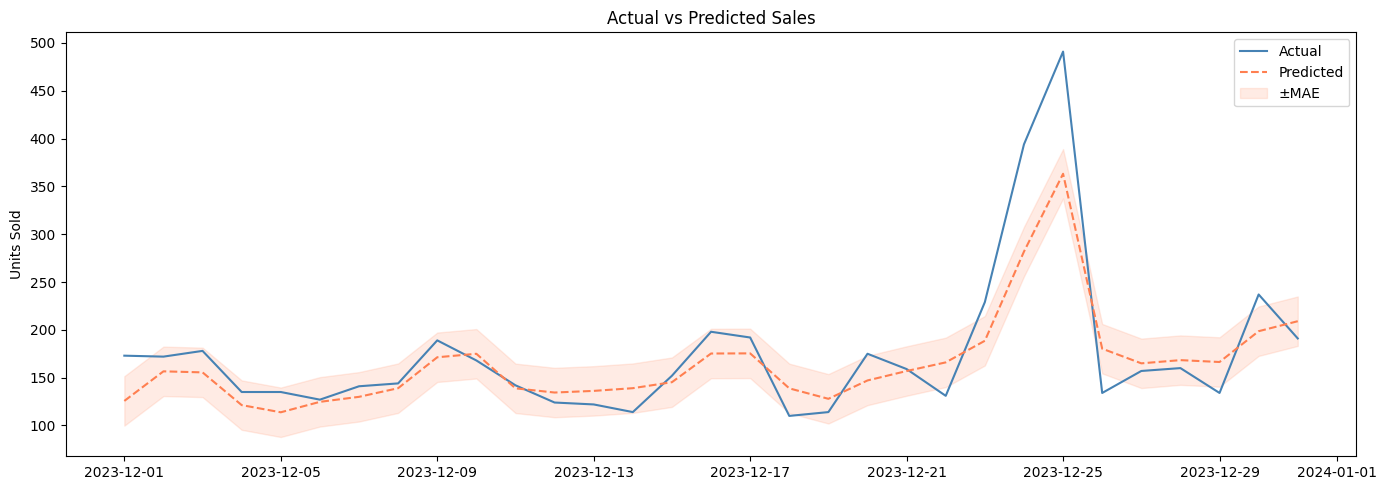

In [ ]:
best_result = min(results, key=lambda x: x['MAE'])

print("Best model:", best_result['model'],
      "(MAE =", round(best_result['MAE'], 2), ")")

plt.figure(figsize=(14,5))

# Actual sales
plt.plot(
    y_test.index,
    y_test.values,
    color='steelblue',
    linewidth=1.5,
    label='Actual'
)

# Predicted sales
plt.plot(
    y_test.index,
    best_result['predictions'],
    color='coral',
    linestyle='--',
    linewidth=1.5,
    label='Predicted'
)

plt.fill_between(
    y_test.index,
    best_result['predictions'] - best_result['MAE'],
    best_result['predictions'] + best_result['MAE'],
    color='coral',
    alpha=0.15,
    label='±MAE'
)

plt.title('Actual vs Predicted Sales')
plt.ylabel('Units Sold')
plt.legend()

plt.tight_layout()
plt.savefig('reports/13_predictions_vs_actuals.png')

plt.show()

## **Residual Analysis (Best Model)**

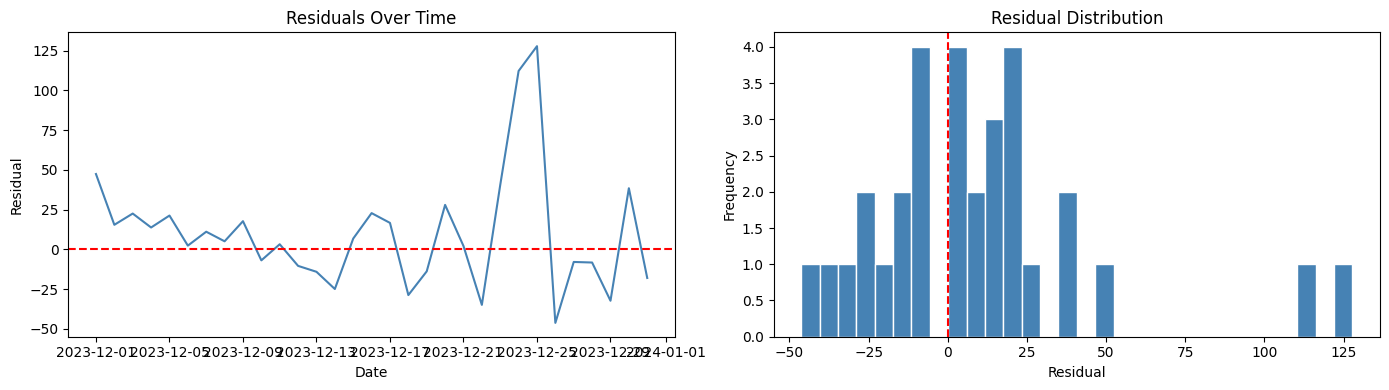

Residual mean : 9.8949
Residual std  : 36.624
Max overshoot : 127.77
Max undershoot: -46.31


In [54]:
# Residuals
residuals = y_test.values - best_result['predictions']

plt.figure(figsize=(14,4))

# Residuals over time
plt.subplot(1,2,1)
plt.plot(y_test.index, residuals, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual')

# Histogram
plt.subplot(1,2,2)
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print values
print("Residual mean :", round(residuals.mean(), 4))
print("Residual std  :", round(residuals.std(), 4))
print("Max overshoot :", round(residuals.max(), 2))
print("Max undershoot:", round(residuals.min(), 2))